# 06 - Compare all models (steps 6 and 7)
**Task:** predict whether a mortgage is fully prepaid within 24 months (`1`) or not (`0`).

This notebook only **reads the saved results** of notebooks 02-05 (`results/metrics`, `results/confusion_matrices`). It trains nothing and never touches the raw data. It:
1. loads the test metrics of all seven result sets (Logistic Regression, the three SVM kernels, LDA, QDA, Neural Network) and **re-computes them from the saved test predictions** as a consistency check,
2. writes one comparison table (`results/metrics/model_comparison.csv` / `.md`),
3. writes three final plots to `results/plots/` (`final_*.png`).

In [3]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)

# ---- Paths: find the project root = the folder that contains model results ----
# Works when Jupyter is started in the project root, in notebooks/, or in any other sub-folder
# (for example "Model comparison/"), also when the repo is nested as ML-Mini-Project/ML-Mini-Project/. If auto-detection ever fails, set PROJECT_ROOT_OVERRIDE by hand.
PROJECT_ROOT_OVERRIDE = None          # e.g. r"P:\ML-Mini-Project"
MARKER = os.path.join("results", "metrics", "logistic_regression_metrics.json")

def find_project_root(start):
    cur = os.path.abspath(start)
    for _ in range(5):                                   # this folder, then up to 4 parents
        try:
            children = [os.path.join(cur, d) for d in sorted(os.listdir(cur))     # nested repo folder only
                        if d.lower() == "ml-mini-project" and os.path.isdir(os.path.join(cur, d))]
        except OSError:
            children = []
        for cand in [cur] + children:                    # also look one level down (nested repo folder)
            if os.path.isfile(os.path.join(cand, MARKER)):
                return cand
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    return None

PROJECT_ROOT = PROJECT_ROOT_OVERRIDE or find_project_root(os.getcwd())
if PROJECT_ROOT is None:
    raise FileNotFoundError(f"Could not find a results/metrics folder near {os.getcwd()} "
                            "(searched this folder, up to 4 parent folders and any ML-Mini-Project sub-folder). "
                            "Set PROJECT_ROOT_OVERRIDE above to the folder that contains results/.")
print("Project root:", PROJECT_ROOT)
METRICS_DIR = os.path.join(PROJECT_ROOT, "results", "metrics")
CM_DIR = os.path.join(PROJECT_ROOT, "results", "confusion_matrices")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "results", "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Every model result set in the repo (file tag -> display name), in a fixed order used by all tables and plots.
MAIN = {
    "logistic_regression": "Logistic Regression",
    "svm": "SVM (RBF)",
    "svm_polynomial": "SVM (Polynomial)",
    "svm_sigmoid": "SVM (Sigmoid)",
    "gda_linear": "GDA - LDA",
    "gda_quadratic": "GDA - QDA",
    "neural_network": "Neural Network",
}

KEYS = ["accuracy", "precision", "recall", "f1", "roc_auc", "tn", "fp", "fn", "tp"]

Project root: c:\ML-Mini-Project\ML-Mini-Project


## 1. Load every model's saved results
The metrics JSONs use two layouts (logistic regression / neural network nest the numbers under `test_metrics`; SVM / GDA store them at the top level), so both are handled and turned into one format.

In [4]:
def load_model(tag):
    with open(os.path.join(METRICS_DIR, f"{tag}_metrics.json")) as f:
        j = json.load(f)
    m = j["test_metrics"] if "test_metrics" in j else j      # nested vs flat layout
    metrics = {k: m[k] for k in KEYS}
    pred = pd.read_csv(os.path.join(METRICS_DIR, f"{tag}_test_predictions.csv"))
    score_col = "decision_score" if "decision_score" in pred.columns else "y_prob"
    cm = pd.read_csv(os.path.join(CM_DIR, f"{tag}_confusion_matrix.csv"), index_col=0)
    return metrics, pred, score_col, cm

ALL = MAIN

# Fail early with a clear list if any result file is missing (e.g. a teammate's files were not pulled yet).
missing = []
for tag in ALL:
    for folder, fname in ((METRICS_DIR, f"{tag}_metrics.json"), (METRICS_DIR, f"{tag}_test_predictions.csv"),
                          (CM_DIR, f"{tag}_confusion_matrix.csv")):
        if not os.path.isfile(os.path.join(folder, fname)):
            missing.append(os.path.join("results", os.path.basename(folder), fname))
if missing:
    raise FileNotFoundError(f"{len(missing)} result file(s) missing under {PROJECT_ROOT}:\n  " + "\n  ".join(missing)
                            + "\nPull the latest version of the GitHub repo (or copy these files in) and run again.")

data = {tag: load_model(tag) for tag in ALL}
print("Loaded:", ", ".join(ALL.values()))

Loaded: Logistic Regression, SVM (RBF), SVM (Polynomial), SVM (Sigmoid), GDA - LDA, GDA - QDA, Neural Network


## 2. Consistency checks
Every number in the final table must agree with the saved predictions and confusion matrices, and every model must have been scored on the **same** test rows.

In [5]:
y_ref = data["logistic_regression"][1]["y_true"].values
rows = []
for tag, name in ALL.items():
    metrics, pred, score_col, cm = data[tag]
    y, yp, s = pred["y_true"].values, pred["y_pred"].values, pred[score_col].values
    assert np.array_equal(y, y_ref), f"{name}: y_true differs from the other models (different test set?)"
    tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0, 1]).ravel()
    re = {"accuracy": accuracy_score(y, yp), "precision": precision_score(y, yp, zero_division=0),
          "recall": recall_score(y, yp, zero_division=0), "f1": f1_score(y, yp, zero_division=0),
          "roc_auc": roc_auc_score(y, s)}
    max_diff = max(abs(re[k] - metrics[k]) for k in re)
    counts_ok = [tn, fp, fn, tp] == [metrics[k] for k in ("tn", "fp", "fn", "tp")]
    cm_ok = cm.values.tolist() == [[tn, fp], [fn, tp]]
    rows.append({"model": name, "n_test": len(y), "max |recomputed - saved|": f"{max_diff:.1e}",
                 "counts match": counts_ok, "confusion CSV matches": cm_ok})
    assert max_diff < 1e-4 and counts_ok and cm_ok, f"{name}: saved metrics disagree with saved predictions"
print(pd.DataFrame(rows).to_string(index=False))
print("\nAll models use the same", len(y_ref), "test rows; class balance:", np.round(y_ref.mean(), 4))

              model  n_test max |recomputed - saved|  counts match  confusion CSV matches
Logistic Regression    9823                  6.2e-08          True                   True
          SVM (RBF)    9823                  0.0e+00          True                   True
   SVM (Polynomial)    9823                  0.0e+00          True                   True
      SVM (Sigmoid)    9823                  0.0e+00          True                   True
          GDA - LDA    9823                  0.0e+00          True                   True
          GDA - QDA    9823                  0.0e+00          True                   True
     Neural Network    9823                  2.1e-07          True                   True

All models use the same 9823 test rows; class balance: 0.5243


## 3. Comparison table (positive class = 1, test set)

In [6]:
def build_table(mapping):
    t = pd.DataFrame({name: data[tag][0] for tag, name in mapping.items()}).T
    t.index.name = "model"
    t[["tn", "fp", "fn", "tp"]] = t[["tn", "fp", "fn", "tp"]].astype(int)
    return t

main_df = build_table(MAIN)
BASELINE = max(y_ref.mean(), 1 - y_ref.mean())
main_df["acc_vs_majority_baseline"] = main_df["accuracy"] - BASELINE

print(f"Majority-class baseline accuracy on the test set: {BASELINE:.4f}\n")
print(main_df.round(4).to_string())

print("\nBest model per metric:")
for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    print(f"  {k:9s} {main_df[k].idxmax():20s} {main_df[k].max():.4f}")
print("  fewest FP:", main_df["fp"].idxmin(), int(main_df["fp"].min()), "| fewest FN:", main_df["fn"].idxmin(), int(main_df["fn"].min()))

Majority-class baseline accuracy on the test set: 0.5243

                     accuracy  precision  recall      f1  roc_auc    tn    fp    fn    tp  acc_vs_majority_baseline
model                                                                                                              
Logistic Regression    0.6474     0.6621  0.6685  0.6653   0.7004  2916  1757  1707  3443                    0.1231
SVM (RBF)              0.6534     0.6608  0.6963  0.6781   0.7065  2832  1841  1564  3586                    0.1291
SVM (Polynomial)       0.6540     0.6518  0.7299  0.6887   0.7068  2665  2008  1391  3759                    0.1297
SVM (Sigmoid)          0.5448     0.5652  0.5715  0.5683   0.5293  2409  2264  2207  2943                    0.0206
GDA - LDA              0.6472     0.6622  0.6676  0.6649   0.7003  2919  1754  1712  3438                    0.1229
GDA - QDA              0.6289     0.6175  0.7680  0.6846   0.6877  2223  2450  1195  3955                    0.1047
Neural Network

In [7]:
# ---- Save the table: CSV for code, Markdown for the README / report ----
main_df.round(4).to_csv(os.path.join(METRICS_DIR, "model_comparison.csv"))

def to_markdown(df, bold_best=("accuracy", "precision", "recall", "f1", "roc_auc")):
    cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "tn", "fp", "fn", "tp"]
    head = ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "TN", "FP", "FN", "TP"]
    lines = ["| " + " | ".join(head) + " |", "|" + "---|" * len(head)]
    for name, r in df.iterrows():
        cells = []
        for c in cols:
            if c in ("tn", "fp", "fn", "tp"):
                cells.append(f"{int(r[c]):,}")
            else:
                txt = f"{r[c]:.4f}"
                cells.append(f"**{txt}**" if c in bold_best and r[c] == df[c].max() else txt)
        lines.append(f"| {name} | " + " | ".join(cells) + " |")
    return "\n".join(lines)

md_text = ("### Test-set results (positive class = 1, prepayment within 24 months)\n\n"
           + to_markdown(main_df)
           + f"\n\nMajority-class baseline accuracy: {BASELINE:.4f}. Best value per metric in bold.\n")
with open(os.path.join(METRICS_DIR, "model_comparison.md"), "w") as f:
    f.write(md_text)
print(md_text)

### Test-set results (positive class = 1, prepayment within 24 months)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | TN | FP | FN | TP |
|---|---|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.6474 | 0.6621 | 0.6685 | 0.6653 | 0.7004 | 2,916 | 1,757 | 1,707 | 3,443 |
| SVM (RBF) | 0.6534 | 0.6608 | 0.6963 | 0.6781 | 0.7065 | 2,832 | 1,841 | 1,564 | 3,586 |
| SVM (Polynomial) | 0.6540 | 0.6518 | 0.7299 | **0.6887** | 0.7068 | 2,665 | 2,008 | 1,391 | 3,759 |
| SVM (Sigmoid) | 0.5448 | 0.5652 | 0.5715 | 0.5683 | 0.5293 | 2,409 | 2,264 | 2,207 | 2,943 |
| GDA - LDA | 0.6472 | 0.6622 | 0.6676 | 0.6649 | 0.7003 | 2,919 | 1,754 | 1,712 | 3,438 |
| GDA - QDA | 0.6289 | 0.6175 | **0.7680** | 0.6846 | 0.6877 | 2,223 | 2,450 | 1,195 | 3,955 |
| Neural Network | **0.6573** | **0.6756** | 0.6664 | 0.6710 | **0.7094** | 3,025 | 1,648 | 1,718 | 3,432 |

Majority-class baseline accuracy: 0.5243. Best value per metric in bold.



## 4. Final plots
One colour per model, the same in every figure.

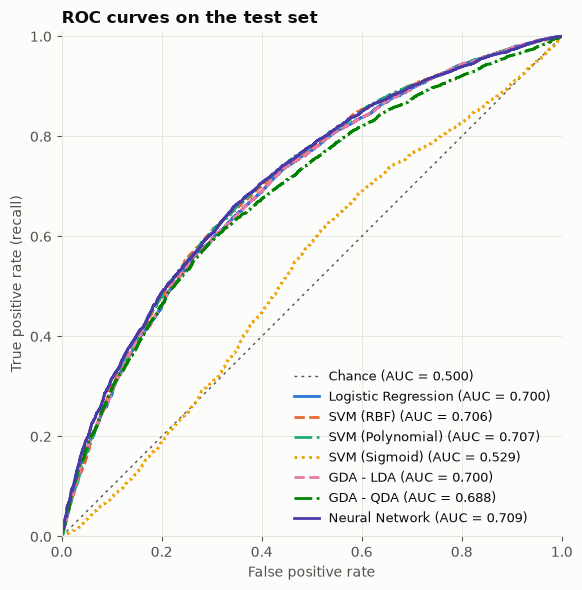

In [8]:
# Shared look: one fixed colour per model (categorical slots 1-7), thin marks, recessive grid, ink text.
SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
COLORS = {"Logistic Regression": "#2a78d6", "SVM (RBF)": "#eb6834", "SVM (Polynomial)": "#1baf7a",
          "SVM (Sigmoid)": "#eda100", "GDA - LDA": "#e87ba4", "GDA - QDA": "#008300", "Neural Network": "#4a3aa7"}
DASH = {"Logistic Regression": "-", "SVM (RBF)": "--", "SVM (Polynomial)": "-.", "SVM (Sigmoid)": ":",
        "GDA - LDA": "--", "GDA - QDA": "-.", "Neural Network": "-"}
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
                     "axes.edgecolor": GRID, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
                     "text.color": INK, "axes.titlecolor": INK, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

# ---------- Plot 1: ROC curves of all models ----------
fig, ax = plt.subplots(figsize=(6.4, 6))
ax.plot([0, 1], [0, 1], color=INK2, lw=1, ls=(0, (2, 3)), label="Chance (AUC = 0.500)")
for tag, name in MAIN.items():
    _, pred, score_col, _ = data[tag]
    fpr, tpr, _ = roc_curve(pred["y_true"], pred[score_col])
    ax.plot(fpr, tpr, color=COLORS[name], ls=DASH[name], lw=2,
            label=f"{name} (AUC = {main_df.loc[name, 'roc_auc']:.3f})")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate (recall)")
ax.set_title("ROC curves on the test set", loc="left", fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.01); ax.set_aspect("equal")
ax.grid(color=GRID, lw=0.6); ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(os.path.join(PLOTS_DIR, "final_roc_curves.png"), dpi=200)
plt.show(); plt.close(fig)

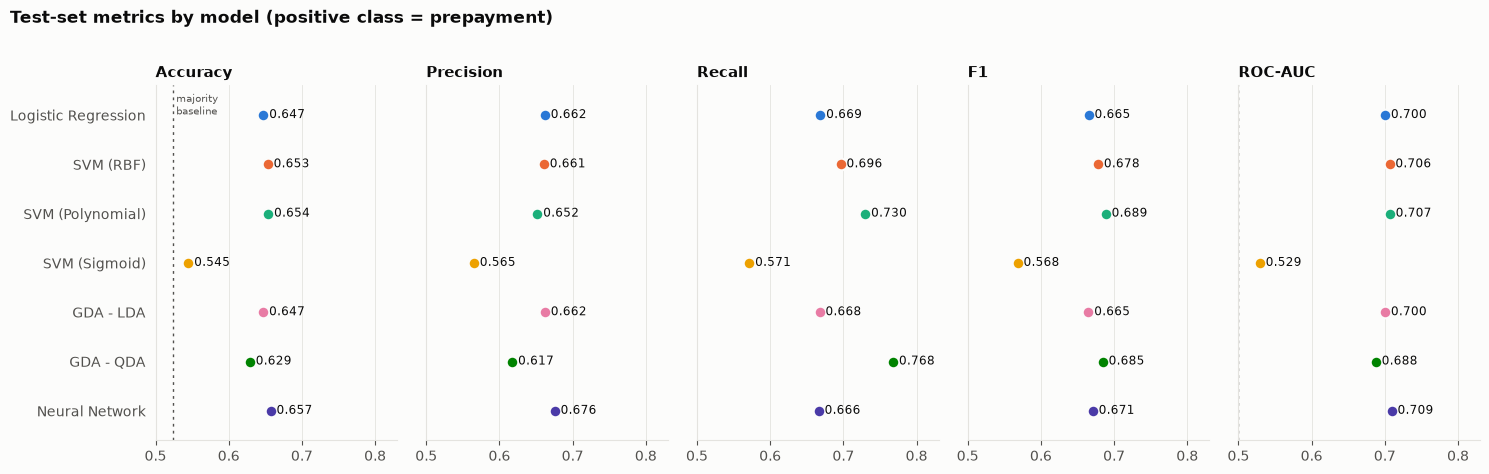

In [9]:
# ---------- Plot 2: metric comparison (dot plot; shared 0.5-0.8 axis so panels are comparable) ----------
metric_cols = [("accuracy", "Accuracy"), ("precision", "Precision"), ("recall", "Recall"),
               ("f1", "F1"), ("roc_auc", "ROC-AUC")]
names = list(MAIN.values())
ypos = np.arange(len(names))[::-1]
fig, axes = plt.subplots(1, 5, figsize=(15, 4.6), sharey=True)
for ax, (col, title) in zip(axes, metric_cols):
    for yp_, name in zip(ypos, names):
        v = main_df.loc[name, col]
        ax.scatter(v, yp_, s=70, color=COLORS[name], edgecolor=SURFACE, linewidth=1.5, zorder=3)
        ax.text(v + 0.008, yp_, f"{v:.3f}", va="center", fontsize=8.5, color=INK)
    ax.set_xlim(0.5, 0.83); ax.set_ylim(-0.6, len(names) - 0.4)
    ax.set_xticks([0.5, 0.6, 0.7, 0.8]); ax.grid(axis="x", color=GRID, lw=0.6); ax.set_axisbelow(True)
    ax.set_title(title, loc="left", fontsize=10.5, fontweight="bold")
    ax.tick_params(left=False)
    if col == "accuracy":
        ax.axvline(BASELINE, color=INK2, lw=1, ls=(0, (2, 3)))
        ax.text(BASELINE + 0.004, len(names) - 0.55, "majority\nbaseline", fontsize=7.5, color=INK2, va="top")
    if col == "roc_auc":
        ax.axvline(0.5, color=INK2, lw=1, ls=(0, (2, 3)))
axes[0].set_yticks(ypos); axes[0].set_yticklabels(names)
fig.suptitle("Test-set metrics by model (positive class = prepayment)", x=0.01, ha="left", fontweight="bold", y=1.02)
fig.tight_layout(); fig.savefig(os.path.join(PLOTS_DIR, "final_metrics_comparison.png"), dpi=200, bbox_inches="tight")
plt.show(); plt.close(fig)

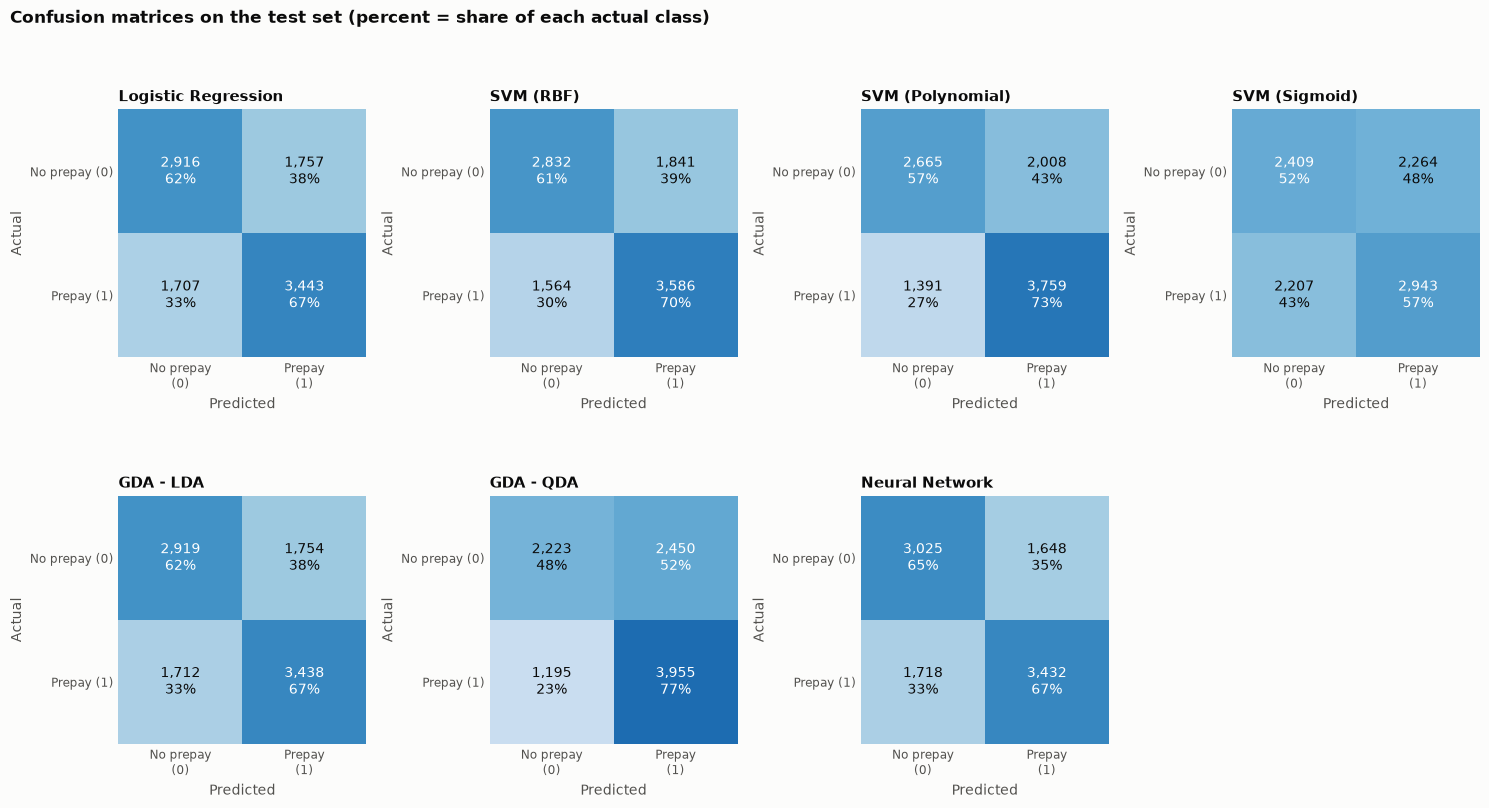

saved   c:\ML-Mini-Project\ML-Mini-Project\results\metrics/model_comparison.csv
saved   c:\ML-Mini-Project\ML-Mini-Project\results\metrics/model_comparison.md
saved   c:\ML-Mini-Project\ML-Mini-Project\results\plots/final_roc_curves.png
saved   c:\ML-Mini-Project\ML-Mini-Project\results\plots/final_metrics_comparison.png
saved   c:\ML-Mini-Project\ML-Mini-Project\results\plots/final_confusion_matrices.png


In [10]:
# ---------- Plot 3: confusion matrices side by side (counts and share of each actual class) ----------
fig, axes_grid = plt.subplots(2, 4, figsize=(15, 8.2))
axes = axes_grid.ravel()
axes[-1].axis("off")                      # 7 models -> last cell of the 2x4 grid is empty
cm_cmap = plt.get_cmap("Blues")
for ax, (tag, name) in zip(axes, MAIN.items()):
    cm = data[tag][3].values
    pct = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(pct, cmap=cm_cmap, vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n{pct[i, j]:.0%}", ha="center", va="center", fontsize=10,
                    color="white" if pct[i, j] > 0.5 else INK)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No prepay\n(0)", "Prepay\n(1)"], fontsize=8.5)
    ax.set_yticklabels(["No prepay (0)", "Prepay (1)"], fontsize=8.5)
    ax.set_xlabel("Predicted"); ax.set_title(name, loc="left", fontweight="bold", fontsize=10.5)
    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(length=0)
for ax in axes[:7]:
    ax.set_ylabel("Actual")
fig.suptitle("Confusion matrices on the test set (percent = share of each actual class)",
             x=0.01, ha="left", fontweight="bold", y=1.01)
fig.tight_layout(); fig.savefig(os.path.join(PLOTS_DIR, "final_confusion_matrices.png"), dpi=200, bbox_inches="tight")
plt.show(); plt.close(fig)

for f in ("metrics/model_comparison.csv", "metrics/model_comparison.md", "plots/final_roc_curves.png",
          "plots/final_metrics_comparison.png", "plots/final_confusion_matrices.png"):
    p = os.path.join(PROJECT_ROOT, "results", f)
    print(("saved   " if os.path.exists(p) else "MISSING ") + p)

## 5. Reading the comparison 
Numbers are in the table above; check each statement against it before using it.
- **Overall:** five of the seven models cluster tightly (accuracy about 0.647-0.657, ROC-AUC about 0.700-0.709): Logistic Regression, LDA, SVM-RBF, SVM-Polynomial and the Neural Network. All are far above the 0.524 majority baseline, but the differences between them are small, so avoid over-claiming a winner.
- **Weakest models:** the sigmoid-kernel SVM is barely better than the baseline (accuracy 0.545, ROC-AUC 0.529); QDA has the lowest ROC-AUC among the working models (0.688).
- **Precision vs recall:** QDA (recall 0.768) and the polynomial SVM (0.730) catch the most prepayments but pay with more false positives; the Neural Network is the most precise (0.676) with the fewest false positives.
- **Linear vs non-linear:** Logistic Regression and LDA (both linear) are practically identical; the non-linear models (SVM-RBF/Polynomial, Neural Network) are only slightly better.
- **Limitations:** one test split (no confidence intervals), default 0.5 threshold, GDA assumes Gaussian features while many inputs are one-hot, and accuracies are not comparable with the reference paper (see README).